## Laid Line extraction from reflected light images
### 0. Load relevant packages

In [73]:
#%pip install scikit-image opencv-python ipywidgets # ----packages needed to run the algorithm----- 

In [74]:
#packages needed to run the algorithm
import numpy as np
import scipy.io as sio
import matplotlib.pyplot as plt
import cv2 as cv
from skimage.transform import radon, rescale, rotate
from matplotlib import cm
from scipy.signal import find_peaks
from scipy.ndimage import gaussian_filter1d
import time
import ipywidgets as widgets
from IPython.display import display


### 1. Pre-processing
It is necessary to pass the image through the **magic eraser** tool and obtain the result.

Therefore, the image must be cut by hand with a size around 350x350 proportionally side to side; it must be done without exceeding the range of 300 to 450 pixels in size to maintain optimal performance.

Then must be passed through the pixel measurement algorithm and the obtained value corresponding to the number of pixels found in 10 millimeters **must be entered into section 7 laid line density** of this document.

### 2. Patch selection
For patch selection select the area of the image that has the best quality without so much interference as folds, spots or voids that can alter the result.

### 3. Spectral TV decomposition
Code based on e.g. Gilboa et al. (https://guygilboa.net.technion.ac.il/2020/10/09/spectral-total-variation-color/) in Matlab. 

The matlab code adaptated is also disponible in this folder.

Run the matlab code first and load the document matlab document containing the result of the descomposed image here next.

#### 3.1 Load Data

In [75]:
time_start=time.perf_counter()
u_0 = sio.loadmat(r'Matlab_results\filtered_manuscript_3-Cut2.mat') # <<---BLANK SPACE FOR THE MATLAB FILE
dec_phi= u_0['f_H'] 

### 4. Radon transform
Detect laid lines in the Radon domain. 

If you have an **image rotated at 90 degrees, you must to select the box** below in the code after running the code in order to process the image correctly.

Finally it is necessary to run the code again since here to update all these changes in the complete code.


In [76]:
@widgets.interact(
    image_rotation= widgets.Checkbox(value=False, description="Rotate the image 90°")
)
def interactive_radon(image_rotation):

    global image_3d_norm, image_2d, theta, sinogram, dx, dy
    
    #The matrix we obtain after applying spectral decomposition is in 3D (color) and needs to be in 2D (gray scale), so the image must be transformed into a gray scale so that radon can read it (requires a gray scale image)

    #this part allows the original color image to be used to show it in the results of the last section of the algorithm.
    image_3d= dec_phi.copy(). astype(np.float32)
    image_3d_norm = (image_3d - np.min(image_3d)) / (np.max(image_3d) - np.min(image_3d))


    if dec_phi.ndim > 2:
        # Is added along the last axis (spectral textures/bands)
        image_2d = np.sum (dec_phi, axis= -1)
    else:
        image_2d = dec_phi

    if image_rotation == True:
        image_3d_norm = rotate(image_3d_norm, 90)
        image_2d = rotate(image_2d, 90)

    #image_3d_norm= rotate(image_3d_norm, 90) # <-----adjustable parameter----- if the image is horizontal, you have to rotate it without commenting on this line, but instead keep this line commented
    #image_2d = rotate (image_2d, 90) # <-----adjustable parameter----- if the image is horizontal, you have to rotate it without commenting on this line, but instead keep this line commented

    image_2d= image_2d -np.mean(image_2d)

    height, width =image_2d.shape

    #creates an angle vector for projections (0 to 180 degrees)
    theta = np.linspace(0., 180., max(image_2d.shape), endpoint=False)

    #applies the radon transform to the corrected 2d image
    sinogram = radon(image_2d, theta=theta, circle=False) 

    #Display variables are defined for correct visualization of the "extent" in matplotlib
    dx, dy = 0.5 * 180. / max(image_2d.shape), 0.5 / sinogram.shape[0] 

    # Display Radon Transformation
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8,4.2))

    ax1.set_title("Original", fontsize=11)
    ax1.imshow(image_2d, cmap='gray') 

    #allow us to show the radon tranformation
    ax2.set_title("Radon transform\n(Sinogram)", fontsize=11)
    ax2.set_xlabel("Projection angle (deg) - (x-axis)", fontsize=11)
    ax2.set_ylabel("Projection position (pixels) - (y-axis)", fontsize=11)
    ax2.imshow(sinogram, cmap=plt.cm.Greys_r, # <---inverted gray scale
            extent=(-dx, 180.0 + dx, -dy, sinogram.shape[0] + dy), 
            aspect='auto')

    fig.tight_layout()
    plt.show()

interactive(children=(Checkbox(value=False, description='Rotate the image 90°'), Output()), _dom_classes=('wid…

### 5. Cross-section
Take a cross-section along the relevant angle to obtain line peaks. We determine the relevant angle by finding the angle of highest magnitude:

The variable *threshold height* corresponds to the line which we establish to consider all the peaks found over it.

The Variable *threshold margin* is set so that the algorithm does not reach high peaks that do not really correspond to the prodominant inclination in the image. this angle is usually in the center of the graphics.

all these variables can be modified if at some point the results are not the best from the scroll bar located below this section.

In [77]:
# --- Cross-section or global profile of intensities--

@widgets.interact(
    threshold_height= widgets.IntSlider(min=-100, max=300, step=30, value=120, description="Threshold height: ", style={"description_width" : "initial"}),

    margin= widgets.IntSlider(min=0, max=200, step=10, value=145,  description="Threshold margin: ", style={"description_width" : "initial"} )
)
def interactive_cross_section(threshold_height, margin):

    global thet_idx, thet

    x = [] #for the angulos(theta). where the lines are perfectly aligned with the sensor.
    y = [] #for the maximum intensity in the synogram of each angle
    for i in range(theta.shape[0]): #we calculate the maximum intensity over the axis y(0) to calculate each angle to find the laid lines
        y.append(np.max(sinogram[:,i]))
        x.append(theta[i])
    y = np.array(y)
    x = np.array(x)

    #margin to ignore the edges ( first and last 145 pixels, ---IMPORTANT:it could be ajusted in the slider below in the image result---) 
    margin = margin
    y_cropped = y[margin:-margin]
    x_cropped = x[margin:-margin]

    #Search for peaks only in the central area 120
    height = threshold_height #---IMPORTANT: it could be ajusted in the slider below in the image result---
    peaks_y_relatives, _ = find_peaks(y_cropped, height=height)

    # Adjust the indexes to point correctly at the original array
    peaks_y = peaks_y_relatives + margin


    # select the best peak
    if len(peaks_y) > 0:
        # looks for the index inside 'peaks_y' which has the maximum value in 'y'
        best_peak_idx = peaks_y[np.argmax(y[peaks_y])]
        
        thet = x[best_peak_idx]
        thet_idx = best_peak_idx
        print(f"Peak selected in the angle: {thet:.1f}")
    else:
        print("The peak was not found at the set height")

    #to visualize the results
    fig, ax = plt.subplots(1, 1, figsize=(12, 3))
    ax.plot(x, y)

    # the peaks found in the center are drawn
    ax.plot(x[peaks_y], y[peaks_y], "x", color="orange") 
    ax.plot(x, height*np.ones_like(x), "--", color="gray")
    plt.show()

interactive(children=(IntSlider(value=120, description='Threshold height: ', max=300, min=-100, step=30, style…

### 6. Peak detection
Locate peaks with highest magnitude, representing the laid lines based on the angle determined above. The parameter "height" determines the threshold for peak detection and is to be chosen manually, it's etablished in -200 so you don't really need to change that value, only if it's necessary. We include gaussian smoothing of the 1D signal to filter out noise.

In [ ]:
@widgets.interact(
    threshold_height= widgets.IntSlider(min=-400, max=200, step=30, value=-200, description="Threshold height: ", style={"description_width" : "initial"})
)
def interactive_threshold(threshold_height):

    global peaks
    
    height = threshold_height #---IMPORTANT: it could be ajusted in the slider below in the image result---


    std = 1 # standard deviation of the gaussian kernel for filtering
    fil=1
    if fil ==1:
        sino = gaussian_filter1d(sinogram[:,thet_idx],std) # smoothing of the signal
    else:
        sino = sinogram[:,thet_idx]


    peaks, _ = find_peaks(sino, height=height)

    fig, ax = plt.subplots(1, 1, figsize=(12, 4))
    ax.plot(sino)

    if len(peaks)>0:
        ax.plot(peaks, sino[peaks], "x", markersize=4, label=f"Detected Peaks:{len(peaks)}")

    ax.plot(height*np.ones_like(sinogram[:,thet_idx]), "--", color="gray", label=f"Actual Threshold:{threshold_height}")

    plt.show()


interactive(children=(IntSlider(value=-200, description='Threshold height: ', max=200, min=-400, step=30, styl…

### 7. Laid Line density measurement and plotting
here we plot the laid lines found in the last step to draw them into the original image 

#### Laid line density measurement

You need to enter into the blank space the number of pixels found in 10 millimeters from the original image of the manuscript. 
The blank space is located at the bottom where the results are the numbers of pixels found in 10 millimeters.
This measure is usually obtained from the execution of the pixel measurement code that you can found in the folder of this code.

In [79]:
@widgets.interact(
    pixels_in_10mm = widgets.FloatText(value=60.80, description="Pixeles in 10 mm: ", step=0.1, style={"description_width":"initial"})
)
def interactive_calcule(pixels_in_10mm):
    try:
        # Prevent division by zero if the box is empty or at 0
        if pixels_in_10mm <= 0:
            print("Expecting a value greater than 0...")
            return
            
        px_per_mm = pixels_in_10mm / 10.0

        patch_height = dec_phi.shape[0]
        patch_width = dec_phi.shape[1]

        patch_pixels_size = patch_height

        # Calculation of the physique size in milimeters
        patch_size_mm = patch_pixels_size / px_per_mm

        # Calculation of average lines per milimeter
        num_avg_par_mm = len(peaks) / patch_size_mm

        # Calculation of average lines for 20 milimeters
        num_avg_20mm = num_avg_par_mm * 20.0
        num_avg_10mm = num_avg_par_mm * 10.0

        print(f"There are approximately: {len(peaks)} lines in this patch")
        print(f"The size patch is: {patch_height} height x {patch_width} width in pixels")
        print(f"The physical patch height size in milimeters is: {patch_size_mm:.1f} mm")
        print(f"The average number of laid lines in 10 milimeters are: {num_avg_10mm:.1f}")
        print(f"The average number of laid lines in 20 milimeters are: {num_avg_20mm:.1f}")
        
    except NameError as e:
        print(f"ERROR: Previous cell to run is missing. Variable not found:{e}")
    except Exception as e:
        print(f"Unexpected error: {e}")

interactive(children=(FloatText(value=60.8, description='Pixeles in 10 mm: ', step=0.1, style=DescriptionStyle…

#### Ploting
Here we take all the information found previously and draw the lines found in the original image.

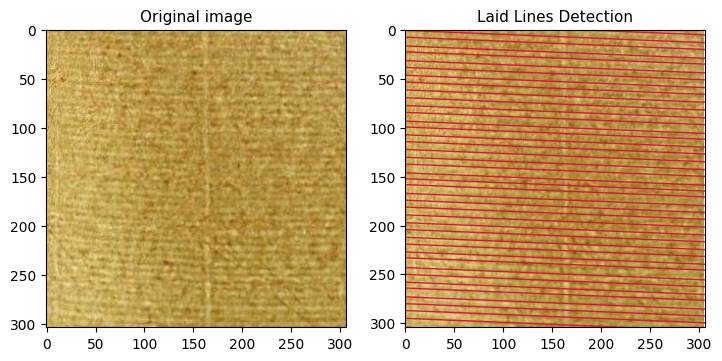

----------------------------------------
Total time execution: 7.00 seconds


In [80]:
# The exact centers of the imaging coordinate systems are searched to draw the laid lines found by the algorithm
c_y = image_2d.shape[0] / 2.0
c_x = image_2d.shape[1] / 2.0
c_proj = sinogram.shape[0] / 2.0

theta_rad = np.deg2rad(thet)

#se establece el diseño de la figura que contiene el resultado mostrada en la parte inferior
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8.5, 4.3))

ax1.set_title("Original image", fontsize=11)
ax1.imshow(image_3d_norm)

ax2.set_title("Laid Lines Detection", fontsize=11)
ax2.imshow(image_3d_norm)

#Se encuentran los picos respectivos
for peak in peaks:
    #  Distancia real del pico respecto al centro del sinograma expandido
    rho = peak - c_proj
    
    # Se proyecta esa distancia (rho) como un punto (x0, y0) partiendo desde el centro de la imagen
    x0 = c_x + rho * np.cos(theta_rad)
    y0 = c_y + rho * np.sin(theta_rad)
    
    # Se dibujar la línea infinita pasando por (x0, y0). 
    # La pendiente perpendicular es idéntica a -np.tan(theta_rad + np.pi/2), simplificada a -1/tan
    ax2.axline((x0, y0), slope=-1/np.tan(-theta_rad), linewidth=1, color="crimson")

#  Se congela los límites para evitar que las líneas infinitas de 'axline' alejen/compriman el zoom de la imagen
ax2.set_xlim(0, image_2d.shape[1])
ax2.set_ylim(image_2d.shape[0], 0)

#plt.tight_layout()
plt.show()

#Se calcula el tiempo transcurrido de la ejecución de todo el programa
time_end=time.perf_counter()
total_time= time_end - time_start

seconds= total_time % 60

print("-" * 40)
print(f"Total time execution: {seconds:.2f} seconds")
